# 📊 Analisis Regresi Linier — Dataset Forecasting

**Tujuan:** Menemukan pola hubungan antara variabel produk (X) terhadap Total_Sales (Y)  
**Metode:** Regresi Linier Berganda (Multiple Linear Regression)  
**Evaluasi:** R², RMSE, MAE, Uji F (simultan), Uji t (parsial)

---

## Alur Analisis
1. Import Library & Load Data  
2. Eksplorasi Data (EDA)  
3. Pra-Pemrosesan: Handling Missing Value & Deteksi Outlier  
4. Pemodelan: Split Data Training & Testing + Fitting Model  
5. Evaluasi Model (R², RMSE, MAE)  
6. Uji Statistik: Uji F & Uji t  
7. Kesimpulan

---
## 1. Import Library & Load Data

In [2]:
# ─── Import Library ───────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.preprocessing import StandardScaler

import scipy.stats as stats
import statsmodels.api as sm

# Konfigurasi tampilan
pd.set_option('display.max_columns', 20)
pd.set_option('display.float_format', '{:.4f}'.format)
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.family'] = 'DejaVu Sans'
sns.set_theme(style='whitegrid', palette='muted')

print('✅ Semua library berhasil diimport!')

✅ Semua library berhasil diimport!


In [3]:
# ─── Load Data ────────────────────────────────────────────────────────────────
FILE_PATH = 'Dataset_Forecasting_ARIMA_Lengkap.xlsx'

df_raw = pd.read_excel(FILE_PATH)
print(f'✅ Data berhasil dimuat: {df_raw.shape[0]} baris × {df_raw.shape[1]} kolom')
print(f'Kolom: {df_raw.columns.tolist()}')

✅ Data berhasil dimuat: 370 baris × 39 kolom
Kolom: ['Date', 'AERIS10', 'GB-BB-10', 'GB-BB-30', 'BR45', 'BR75', 'GB-TP-CC', 'GB-CNF-30', 'GB-CNF-10', 'GB-CNF-100', 'GB-CNF-250', 'GB-DS-30', 'GB-DS-10', 'GB-DS-100', 'GB-DS-250', 'EC45', 'EC75', 'GB-GF-30', 'GB-GF-10', 'GB-GF-250', 'GB-IB-30', 'GB-IB-10', 'GB-IB-100', 'GB-JOY-30', 'GB-JOY-10', 'GB-JOY-100', 'GB-LDR-30', 'GB-LDR-10', 'GB-LDR-250', 'GB-MYB-30', 'GB-MYB-10', 'GB-MYB-100', 'GB-TP-NB', 'GB-TC-30', 'GB-TC-10', 'GB-TC-250', 'TEETH10', 'GB-TP-TV', 'Total_Sales']


---
## 2. Eksplorasi Data (EDA)
Mencari pola hubungan antarvariabel sebelum pemodelan.

In [4]:
# ─── Tampilkan 5 baris pertama ────────────────────────────────────────────────
print('=== Preview Data (5 baris pertama) ===')
df_raw.head()

=== Preview Data (5 baris pertama) ===


,Date,AERIS10,GB-BB-10,GB-BB-30,BR45,BR75,GB-TP-CC,GB-CNF-30,GB-CNF-10,GB-CNF-100,...,GB-MYB-30,GB-MYB-10,GB-MYB-100,GB-TP-NB,GB-TC-30,GB-TC-10,GB-TC-250,TEETH10,GB-TP-TV,Total_Sales
0,2025-01-01 00:00:00,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,...,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
1,2025-01-02 00:00:00,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,3.0000,14.0000,0.0000,...,0.0000,3.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,42.0000
2,2025-01-03 00:00:00,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,18.0000,45.0000,0.0000,...,0.0000,0.0000,0.0000,2.0000,3.0000,6.0000,1.0000,0.0000,0.0000,117.0000
3,2025-01-04 00:00:00,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,8.0000,4.0000,0.0000,...,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,13.0000
4,2025-01-05 00:00:00,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,...,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000


In [5]:
# ─── Informasi tipe data & missing value ──────────────────────────────────────
print('=== Info Tipe Data & Jumlah Nilai Tidak Kosong ===')
df_raw.info()

=== Info Tipe Data & Jumlah Nilai Tidak Kosong ===
<class 'pandas.DataFrame'>
RangeIndex: 370 entries, 0 to 369
Data columns (total 39 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Date         368 non-null    object 
 1   AERIS10      368 non-null    float64
 2   GB-BB-10     368 non-null    float64
 3   GB-BB-30     368 non-null    float64
 4   BR45         368 non-null    float64
 5   BR75         368 non-null    float64
 6   GB-TP-CC     368 non-null    float64
 7   GB-CNF-30    368 non-null    float64
 8   GB-CNF-10    368 non-null    float64
 9   GB-CNF-100   368 non-null    float64
 10  GB-CNF-250   368 non-null    float64
 11  GB-DS-30     368 non-null    float64
 12  GB-DS-10     368 non-null    float64
 13  GB-DS-100    368 non-null    float64
 14  GB-DS-250    368 non-null    float64
 15  EC45         368 non-null    float64
 16  EC75         368 non-null    float64
 17  GB-GF-30     368 non-null    float64
 18  GB-GF-10  

In [6]:
# ─── Statistik Deskriptif ─────────────────────────────────────────────────────
print('=== Statistik Deskriptif ===')
df_raw.describe().T

=== Statistik Deskriptif ===


,count,mean,std,min,25%,50%,75%,max
AERIS10,368.0000,0.0218,0.2204,0.0000,0.0000,0.0000,0.0000,3.0000
GB-BB-10,368.0000,0.2721,2.5136,0.0000,0.0000,0.0000,0.0000,46.0000
GB-BB-30,368.0000,0.1388,1.2785,0.0000,0.0000,0.0000,0.0000,23.0000
BR45,368.0000,0.1197,1.1204,0.0000,0.0000,0.0000,0.0000,20.0000
BR75,368.0000,0.0082,0.0900,0.0000,0.0000,0.0000,0.0000,1.0000
GB-TP-CC,368.0000,0.7292,6.7324,0.0000,0.0000,0.0000,0.0000,124.0000
GB-CNF-30,368.0000,9.1290,85.7487,0.0000,0.0000,0.0000,5.0000,1635.0000
GB-CNF-10,368.0000,9.0989,84.6796,0.0000,0.0000,0.0000,3.0000,1605.0000
GB-CNF-100,368.0000,0.0354,0.3405,0.0000,0.0000,0.0000,0.0000,6.0000
GB-CNF-250,368.0000,0.0082,0.0900,0.0000,0.0000,0.0000,0.0000,1.0000


In [7]:
# ─── Cek baris non-data di akhir file ─────────────────────────────────────────
print('=== 10 Baris Terakhir (termasuk footer) ===')
df_raw.tail(10)

=== 10 Baris Terakhir (termasuk footer) ===


,Date,AERIS10,GB-BB-10,GB-BB-30,BR45,BR75,GB-TP-CC,GB-CNF-30,GB-CNF-10,GB-CNF-100,...,GB-MYB-30,GB-MYB-10,GB-MYB-100,GB-TP-NB,GB-TC-30,GB-TC-10,GB-TC-250,TEETH10,GB-TP-TV,Total_Sales
360,2025-12-27 00:00:00,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,...,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000
361,2025-12-28 00:00:00,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,...,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
362,2025-12-29 00:00:00,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,...,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,2.0000
363,2025-12-30 00:00:00,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,3.0000,0.0000,0.0000,...,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,3.0000
364,2025-12-31 00:00:00,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,2.0000,0.0000,...,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,2.0000
365,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
366,jumlah,3.0000,46.0000,23.0000,20.0000,1.0000,124.0000,1635.0000,1605.0000,6.0000,...,12.0000,30.0000,1.0000,38.0000,126.0000,169.0000,1.0000,11.0000,11.0000,NaN
367,pemakaian maksimum,2.0000,8.0000,5.0000,4.0000,1.0000,20.0000,85.0000,134.0000,1.0000,...,2.0000,5.0000,1.0000,8.0000,19.0000,18.0000,1.0000,4.0000,2.0000,NaN
368,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
369,pemakaian rata rata,0.0082,0.1260,0.0630,0.0548,0.0027,0.3397,4.4795,4.3973,0.0164,...,0.0329,0.0822,0.0027,0.1041,0.3452,0.4630,0.0027,0.0301,0.0301,NaN


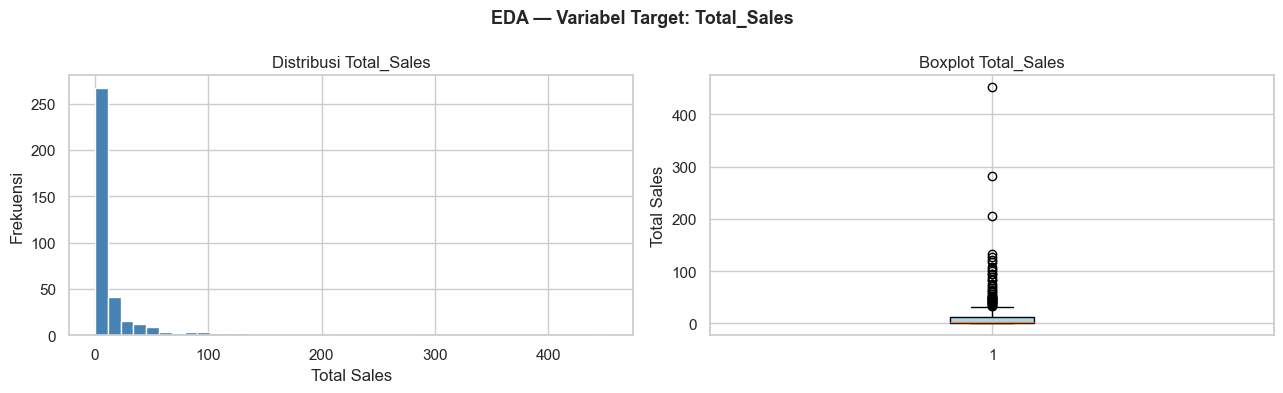

Skewness Total_Sales: 6.9699 (>1 = distribusi condong kanan)


In [8]:
# ─── Distribusi Target Variabel (Total_Sales) ─────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Filter dulu data numerik saja
ts_preview = pd.to_numeric(df_raw['Total_Sales'], errors='coerce').dropna()

axes[0].hist(ts_preview, bins=40, color='steelblue', edgecolor='white')
axes[0].set_title('Distribusi Total_Sales')
axes[0].set_xlabel('Total Sales')
axes[0].set_ylabel('Frekuensi')

axes[1].boxplot(ts_preview, vert=True, patch_artist=True,
                boxprops=dict(facecolor='lightblue'))
axes[1].set_title('Boxplot Total_Sales')
axes[1].set_ylabel('Total Sales')

plt.suptitle('EDA — Variabel Target: Total_Sales', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()
print(f'Skewness Total_Sales: {ts_preview.skew():.4f} (>1 = distribusi condong kanan)')

---
## 3. Pra-Pemrosesan Data
### 3a. Handling Missing Value

In [9]:
# ─── Bersihkan baris footer (bukan data tanggal) ──────────────────────────────
# Baris footer berisi string seperti 'jumlah', 'pemakaian maksimum', dll.
# Strategi: ambil hanya baris dengan kolom Date berformat datetime

df = df_raw.copy()
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')  # non-date → NaT
df = df[df['Date'].notna()].reset_index(drop=True)        # buang baris NaT

# Konversi semua kolom numerik
feature_cols = [c for c in df.columns if c != 'Date']
df[feature_cols] = df[feature_cols].apply(pd.to_numeric, errors='coerce')

print(f'Ukuran data setelah hapus footer: {df.shape}')
print(f'Rentang tanggal: {df["Date"].min().date()} s.d. {df["Date"].max().date()}')

Ukuran data setelah hapus footer: (365, 39)
Rentang tanggal: 2025-01-01 s.d. 2025-12-31


In [10]:
# ─── Cek Missing Value ────────────────────────────────────────────────────────
missing = df[feature_cols].isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
missing_has = missing_df[missing_df['Missing Count'] > 0]

if missing_has.empty:
    print('✅ Tidak ada missing value pada data numerik.')
else:
    print('⚠️  Kolom dengan Missing Value:')
    print(missing_has)

✅ Tidak ada missing value pada data numerik.


In [11]:
# ─── Imputasi Missing Value dengan Median ─────────────────────────────────────
# Median dipilih karena distribusi data penjualan cenderung right-skewed
# sehingga median lebih robust terhadap outlier dibanding mean.

before_missing = df[feature_cols].isnull().sum().sum()

for col in feature_cols:
    if df[col].isnull().any():
        median_val = df[col].median()
        df[col].fillna(median_val, inplace=True)
        print(f'  [{col}] → diisi median = {median_val:.4f}')

after_missing = df[feature_cols].isnull().sum().sum()
print(f'\n✅ Missing value: {before_missing} → {after_missing} (setelah imputasi)')


✅ Missing value: 0 → 0 (setelah imputasi)


### 3b. Deteksi & Penanganan Outlier

In [12]:
# ─── Deteksi Outlier dengan Metode IQR ───────────────────────────────────────
# Outlier: nilai di bawah Q1-1.5*IQR atau di atas Q3+1.5*IQR

target_col = 'Total_Sales'
Q1 = df[target_col].quantile(0.25)
Q3 = df[target_col].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outlier_mask = (df[target_col] < lower_bound) | (df[target_col] > upper_bound)
n_outlier = outlier_mask.sum()

print(f'=== Deteksi Outlier pada {target_col} ===')
print(f'  Q1          : {Q1:.2f}')
print(f'  Q3          : {Q3:.2f}')
print(f'  IQR         : {IQR:.2f}')
print(f'  Batas Bawah : {lower_bound:.2f}')
print(f'  Batas Atas  : {upper_bound:.2f}')
print(f'  Jumlah Outlier: {n_outlier} dari {len(df)} baris ({n_outlier/len(df)*100:.1f}%)')

=== Deteksi Outlier pada Total_Sales ===
  Q1          : 0.00
  Q3          : 13.00
  IQR         : 13.00
  Batas Bawah : -19.50
  Batas Atas  : 32.50
  Jumlah Outlier: 42 dari 365 baris (11.5%)


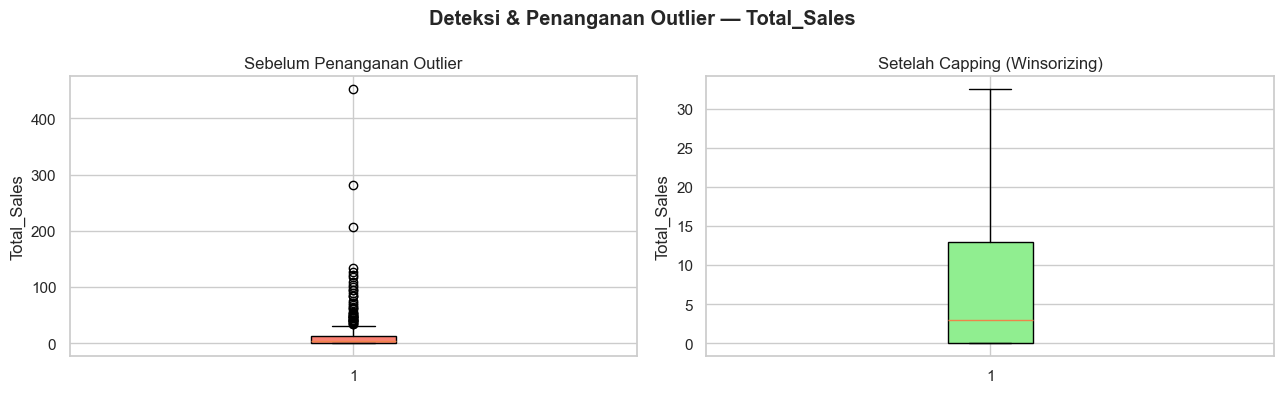


✅ Outlier ditangani dengan Winsorizing (Capping).
   Nilai di luar [-19.50, 32.50] dipotong ke batas tersebut.


In [13]:
# ─── Visualisasi Outlier ──────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Sebelum penanganan
axes[0].boxplot(df[target_col], patch_artist=True,
                boxprops=dict(facecolor='salmon'))
axes[0].set_title('Sebelum Penanganan Outlier')
axes[0].set_ylabel('Total_Sales')

# Capping / Winsorizing
df[target_col + '_clean'] = df[target_col].clip(lower=lower_bound, upper=upper_bound)

axes[1].boxplot(df[target_col + '_clean'], patch_artist=True,
                boxprops=dict(facecolor='lightgreen'))
axes[1].set_title('Setelah Capping (Winsorizing)')
axes[1].set_ylabel('Total_Sales')

plt.suptitle('Deteksi & Penanganan Outlier — Total_Sales', fontweight='bold')
plt.tight_layout()
plt.show()

# Gunakan versi yang sudah di-capping
df[target_col] = df[target_col + '_clean']
df.drop(columns=[target_col + '_clean'], inplace=True)
print(f'\n✅ Outlier ditangani dengan Winsorizing (Capping).')
print(f'   Nilai di luar [{lower_bound:.2f}, {upper_bound:.2f}] dipotong ke batas tersebut.')

---
## 4. Pemodelan Regresi Linier
### 4a. Seleksi Fitur & Korelasi

In [14]:
# ─── Korelasi Fitur terhadap Target ──────────────────────────────────────────
X_all = df.drop(columns=['Date', 'Total_Sales'])
y     = df['Total_Sales']

corr = X_all.corrwith(y).sort_values(ascending=False)
print('=== Korelasi Pearson (X → Total_Sales) ===')
print(corr.to_string())

=== Korelasi Pearson (X → Total_Sales) ===
GB-CNF-30     0.6735
GB-CNF-10     0.5681
GB-DS-10      0.5671
GB-JOY-10     0.5309
GB-JOY-30     0.4995
GB-TC-10      0.4988
GB-IB-30      0.4801
GB-DS-30      0.4419
GB-TC-30      0.4410
GB-IB-10      0.4265
GB-GF-30      0.4003
GB-GF-10      0.3915
GB-TP-CC      0.3475
GB-LDR-10     0.3147
GB-MYB-10     0.3047
GB-TP-NB      0.2895
GB-BB-10      0.2550
GB-MYB-30     0.2386
GB-TP-TV      0.2378
GB-LDR-30     0.2292
GB-CNF-100    0.1870
GB-DS-100     0.1713
GB-DS-250     0.1667
GB-IB-100     0.1331
GB-BB-30      0.1242
BR45          0.1233
EC45          0.1170
GB-TC-250     0.1142
GB-MYB-100    0.1142
GB-CNF-250    0.1142
GB-LDR-250    0.1142
EC75          0.1142
BR75          0.1142
GB-JOY-100    0.0642
GB-GF-250     0.0596
AERIS10      -0.0433
TEETH10      -0.0567


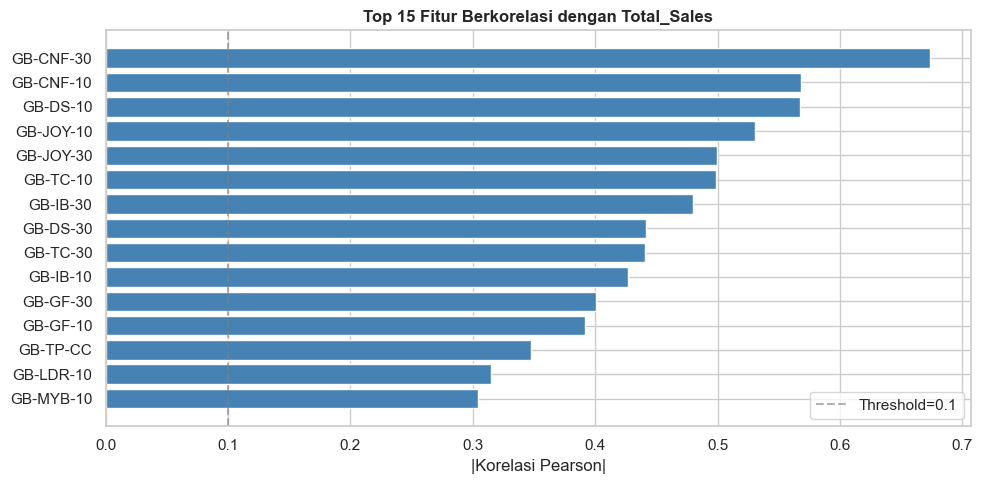

In [15]:
# ─── Visualisasi Korelasi (Top 15) ───────────────────────────────────────────
top_corr = corr.abs().sort_values(ascending=False).head(15)

plt.figure(figsize=(10, 5))
colors = ['steelblue' if corr[i] >= 0 else 'tomato' for i in top_corr.index]
plt.barh(top_corr.index[::-1], top_corr.values[::-1], color=colors[::-1])
plt.axvline(x=0.1, color='gray', linestyle='--', alpha=0.6, label='Threshold=0.1')
plt.xlabel('|Korelasi Pearson|')
plt.title('Top 15 Fitur Berkorelasi dengan Total_Sales', fontweight='bold')
plt.legend()
plt.tight_layout()
plt.show()

In [16]:
# ─── Pilih Fitur dengan Korelasi >= 0.05 ────────────────────────────────────
# Threshold rendah karena data penjualan produk cenderung sparse
CORR_THRESHOLD = 0.05
selected_features = corr[corr.abs() >= CORR_THRESHOLD].index.tolist()

# Pastikan minimal ada fitur
if len(selected_features) == 0:
    selected_features = corr.abs().sort_values(ascending=False).head(5).index.tolist()

print(f'Fitur terpilih ({len(selected_features)} fitur, |korelasi| ≥ {CORR_THRESHOLD}):')
for f in selected_features:
    print(f'  {f}: {corr[f]:.4f}')

Fitur terpilih (36 fitur, |korelasi| ≥ 0.05):
  GB-CNF-30: 0.6735
  GB-CNF-10: 0.5681
  GB-DS-10: 0.5671
  GB-JOY-10: 0.5309
  GB-JOY-30: 0.4995
  GB-TC-10: 0.4988
  GB-IB-30: 0.4801
  GB-DS-30: 0.4419
  GB-TC-30: 0.4410
  GB-IB-10: 0.4265
  GB-GF-30: 0.4003
  GB-GF-10: 0.3915
  GB-TP-CC: 0.3475
  GB-LDR-10: 0.3147
  GB-MYB-10: 0.3047
  GB-TP-NB: 0.2895
  GB-BB-10: 0.2550
  GB-MYB-30: 0.2386
  GB-TP-TV: 0.2378
  GB-LDR-30: 0.2292
  GB-CNF-100: 0.1870
  GB-DS-100: 0.1713
  GB-DS-250: 0.1667
  GB-IB-100: 0.1331
  GB-BB-30: 0.1242
  BR45: 0.1233
  EC45: 0.1170
  GB-TC-250: 0.1142
  GB-MYB-100: 0.1142
  GB-CNF-250: 0.1142
  GB-LDR-250: 0.1142
  EC75: 0.1142
  BR75: 0.1142
  GB-JOY-100: 0.0642
  GB-GF-250: 0.0596
  TEETH10: -0.0567


### 4b. Split Data Training & Testing

In [17]:
# ─── Persiapan Fitur & Target ─────────────────────────────────────────────────
X = df[selected_features]
y = df['Total_Sales']

print(f'Dimensi X (fitur) : {X.shape}')
print(f'Dimensi y (target): {y.shape}')

Dimensi X (fitur) : (365, 36)
Dimensi y (target): (365,)


=== Pembagian Data Training & Testing ===
  Total data     : 365 sampel
  Data Training  : 292 sampel (80.0%)
  Data Testing   : 73 sampel (20.0%)


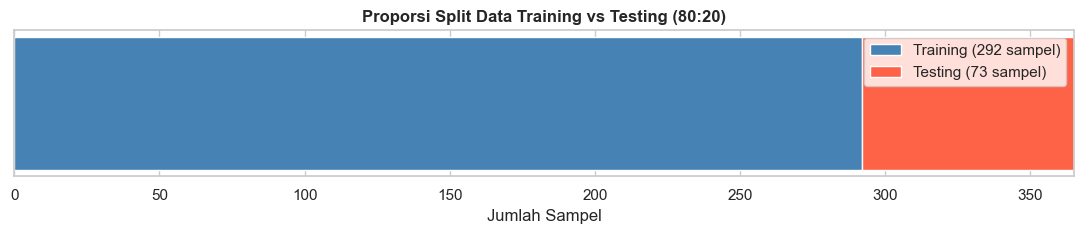

In [18]:
# ─── Split Data: 80% Training, 20% Testing ───────────────────────────────────
# random_state=42 agar hasil reproducible
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42
)

print('=== Pembagian Data Training & Testing ===')
print(f'  Total data     : {len(X)} sampel')
print(f'  Data Training  : {len(X_train)} sampel ({len(X_train)/len(X)*100:.1f}%)')
print(f'  Data Testing   : {len(X_test)} sampel ({len(X_test)/len(X)*100:.1f}%)')

# Visualisasi pembagian data
fig, ax = plt.subplots(figsize=(11, 2.5))
all_idx = list(range(len(X)))
train_idx = sorted(X_train.index.tolist())
test_idx  = sorted(X_test.index.tolist())

ax.barh(0, len(X_train), color='steelblue', label=f'Training ({len(X_train)} sampel)')
ax.barh(0, len(X_test), left=len(X_train), color='tomato', label=f'Testing ({len(X_test)} sampel)')
ax.set_xlim(0, len(X))
ax.set_yticks([])
ax.set_xlabel('Jumlah Sampel')
ax.set_title('Proporsi Split Data Training vs Testing (80:20)', fontweight='bold')
ax.legend(loc='upper right')
plt.tight_layout()
plt.show()

### 4c. Fitting Model Regresi Linier

In [19]:
# ─── Inisialisasi & Fitting Model ────────────────────────────────────────────
model = LinearRegression()
model.fit(X_train, y_train)

print('✅ Model Regresi Linier berhasil di-fitting!')
print(f'\nIntercept (β₀) : {model.intercept_:.4f}')
print('\nKoefisien (β) per fitur:')
coef_df = pd.DataFrame({
    'Fitur': selected_features,
    'Koefisien': model.coef_
}).sort_values('Koefisien', ascending=False)
print(coef_df.to_string(index=False))

✅ Model Regresi Linier berhasil di-fitting!

Intercept (β₀) : 2.8710

Koefisien (β) per fitur:
     Fitur  Koefisien
 GB-DS-250    29.7731
GB-JOY-100     9.5550
 GB-DS-100     7.3050
GB-CNF-250     6.0453
GB-LDR-250     6.0453
      BR45     3.9157
 GB-LDR-30     3.1385
 GB-JOY-10     2.6379
 GB-MYB-10     2.1495
  GB-TP-NB     2.1476
  GB-GF-30     2.1360
  GB-BB-30     1.4725
      EC45     1.0620
  GB-DS-30     1.0414
  GB-IB-30     0.9347
 GB-CNF-30     0.6499
  GB-TC-30     0.5181
 GB-CNF-10     0.4672
GB-MYB-100    -0.0000
   TEETH10    -0.0253
  GB-DS-10    -0.2469
  GB-IB-10    -0.2736
  GB-TP-CC    -0.2918
  GB-BB-10    -0.3718
 GB-IB-100    -0.7063
  GB-GF-10    -0.9141
 GB-LDR-10    -0.9340
 GB-JOY-30    -1.2892
GB-CNF-100    -2.6830
  GB-TC-10    -3.9268
  GB-TP-TV    -4.7268
 GB-MYB-30    -5.8229
 GB-TC-250    -9.4879
 GB-GF-250   -26.5135
      EC75   -60.5778
      BR75   -60.5778


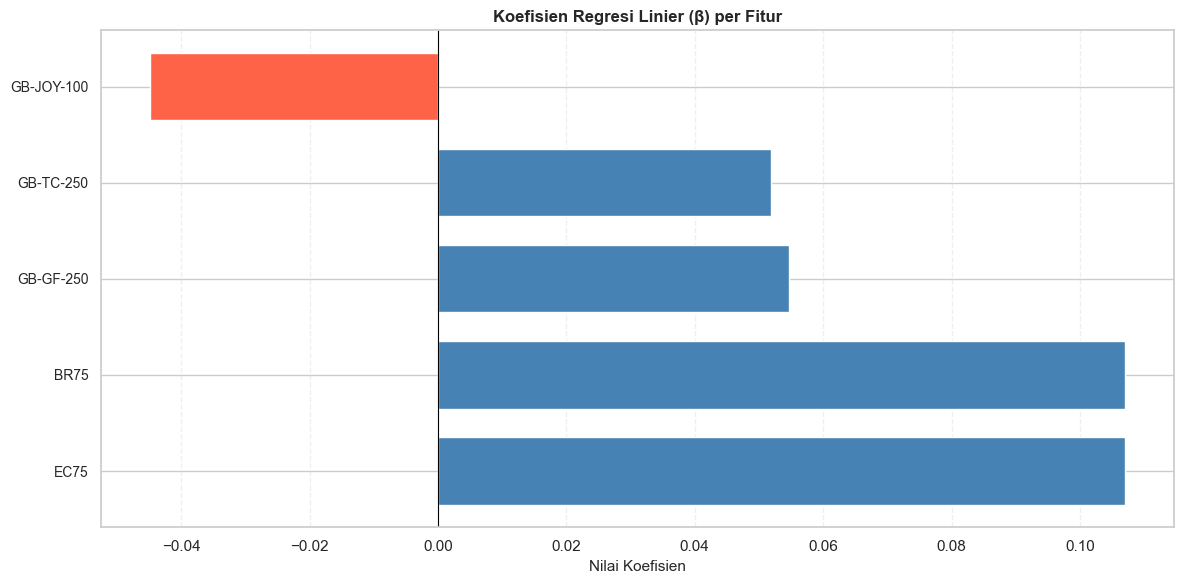

In [41]:
# ─── Visualisasi Koefisien Model ─────────────────────────────────────────────
colors_coef = ['steelblue' if c >= 0 else 'tomato' for c in coef_df['Koefisien']]

# Tentukan ukuran figure berdasarkan jumlah fitur
num_features = len(coef_df)
fig_height = max(6, num_features * 0.25)  # Minimal 6, max sesuai jumlah fitur

fig, ax = plt.subplots(figsize=(12, fig_height))
ax.barh(coef_df['Fitur'], coef_df['Koefisien'], color=colors_coef, height=0.7)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Nilai Koefisien', fontsize=11)
ax.set_title('Koefisien Regresi Linier (β) per Fitur', fontweight='bold', fontsize=12)
ax.tick_params(axis='y', labelsize=10)
ax.grid(axis='x', alpha=0.3, linestyle='--')

plt.subplots_adjust(left=0.15, right=0.95, top=0.95, bottom=0.1)
plt.tight_layout()
plt.show()

In [21]:
# ─── Prediksi ─────────────────────────────────────────────────────────────────
y_pred_train = model.predict(X_train)
y_pred_test  = model.predict(X_test)

print('✅ Prediksi selesai untuk data training dan testing.')

✅ Prediksi selesai untuk data training dan testing.


---
## 5. Evaluasi Model
### Metrik: R², RMSE, MAE

In [22]:
# ─── Hitung Metrik Evaluasi ───────────────────────────────────────────────────
def evaluate_model(y_true, y_pred, label=''):
    r2   = r2_score(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    return {'Set': label, 'R²': r2, 'RMSE': rmse, 'MAE': mae}

train_metrics = evaluate_model(y_train, y_pred_train, 'Training')
test_metrics  = evaluate_model(y_test,  y_pred_test,  'Testing')

eval_df = pd.DataFrame([train_metrics, test_metrics])
eval_df = eval_df.set_index('Set')

print('=== Tabel Evaluasi Model ===')
print(eval_df.to_string())

print('\n📌 Interpretasi:')
print(f'   R²    : {test_metrics["R²"]:.4f} → model menjelaskan {test_metrics["R²"]*100:.1f}% variansi data testing')
print(f'   RMSE  : {test_metrics["RMSE"]:.4f} → rata-rata deviasi kuadrat prediksi')
print(f'   MAE   : {test_metrics["MAE"]:.4f} → rata-rata deviasi absolut prediksi')

=== Tabel Evaluasi Model ===
             R²   RMSE    MAE
Set                          
Training 0.7913 4.9390 3.5714
Testing  0.6023 7.4663 4.8614

📌 Interpretasi:
   R²    : 0.6023 → model menjelaskan 60.2% variansi data testing
   RMSE  : 7.4663 → rata-rata deviasi kuadrat prediksi
   MAE   : 4.8614 → rata-rata deviasi absolut prediksi


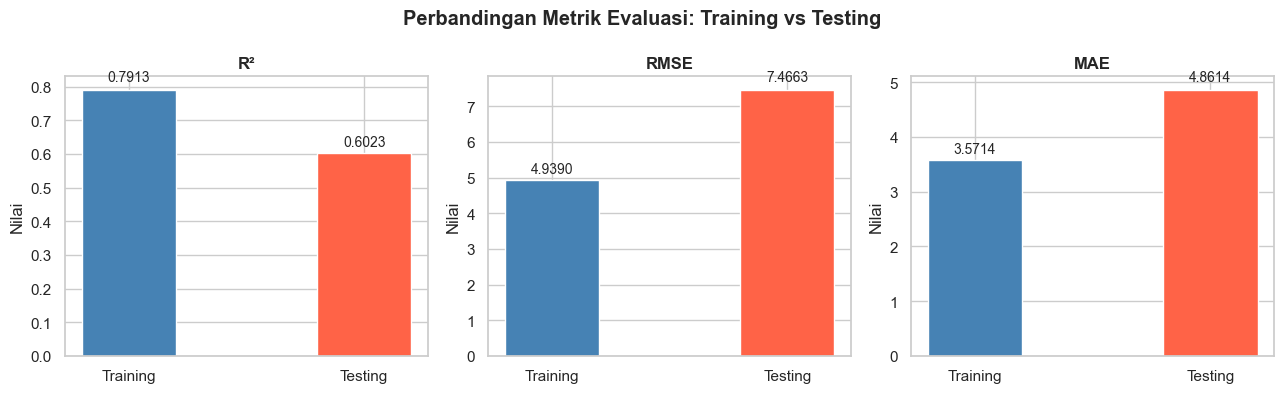

In [23]:
# ─── Visualisasi Metrik ───────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
metrics_list = ['R²', 'RMSE', 'MAE']
colors_bar   = ['steelblue', 'tomato']

for i, metric in enumerate(metrics_list):
    vals  = [train_metrics[metric], test_metrics[metric]]
    bars  = axes[i].bar(['Training', 'Testing'], vals, color=colors_bar, width=0.4)
    axes[i].set_title(metric, fontweight='bold')
    axes[i].set_ylabel('Nilai')
    for bar, val in zip(bars, vals):
        axes[i].text(bar.get_x() + bar.get_width()/2,
                     bar.get_height() * 1.02,
                     f'{val:.4f}', ha='center', va='bottom', fontsize=10)

plt.suptitle('Perbandingan Metrik Evaluasi: Training vs Testing', fontweight='bold')
plt.tight_layout()
plt.show()

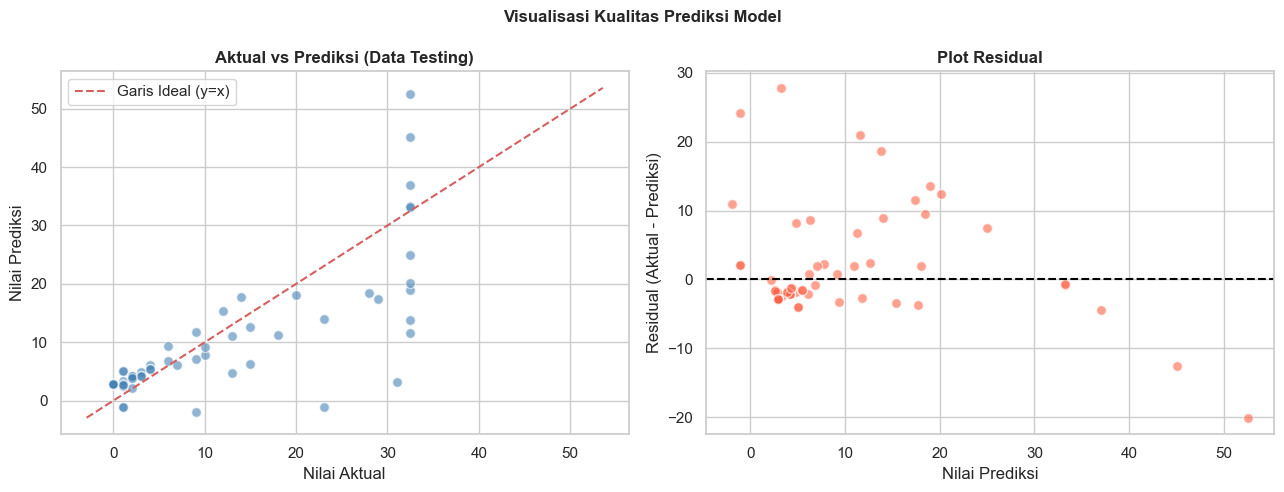

In [24]:
# ─── Scatter: Actual vs Predicted (Testing) ──────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Scatter aktual vs prediksi
axes[0].scatter(y_test, y_pred_test, alpha=0.6, color='steelblue', edgecolors='white', s=50)
lims = [min(y_test.min(), y_pred_test.min()) - 1,
        max(y_test.max(), y_pred_test.max()) + 1]
axes[0].plot(lims, lims, 'r--', label='Garis Ideal (y=x)')
axes[0].set_xlabel('Nilai Aktual')
axes[0].set_ylabel('Nilai Prediksi')
axes[0].set_title('Aktual vs Prediksi (Data Testing)', fontweight='bold')
axes[0].legend()

# Residual plot
residuals = y_test.values - y_pred_test
axes[1].scatter(y_pred_test, residuals, alpha=0.6, color='tomato', edgecolors='white', s=50)
axes[1].axhline(0, color='black', linestyle='--')
axes[1].set_xlabel('Nilai Prediksi')
axes[1].set_ylabel('Residual (Aktual - Prediksi)')
axes[1].set_title('Plot Residual', fontweight='bold')

plt.suptitle('Visualisasi Kualitas Prediksi Model', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 6. Uji Statistik
### 6a. Uji F — Signifikansi Simultan (Semua X terhadap Y)

In [25]:
# ─── Uji F menggunakan statsmodels ───────────────────────────────────────────
# Tambahkan konstanta (intercept) untuk statsmodels
X_train_sm = sm.add_constant(X_train)
X_test_sm  = sm.add_constant(X_test)

ols_model = sm.OLS(y_train, X_train_sm).fit()

# Ekstrak nilai Uji F
f_stat    = ols_model.fvalue
f_pvalue  = ols_model.f_pvalue
alpha     = 0.05

print('=' * 55)
print('  UJI F — Signifikansi Simultan')
print('=' * 55)
print(f'  H₀: Semua koefisien β = 0 (model tidak signifikan)')
print(f'  H₁: Minimal satu β ≠ 0 (model signifikan)')
print(f'  Tingkat signifikansi (α) : {alpha}')
print('-' * 55)
print(f'  F-statistic              : {f_stat:.4f}')
print(f'  p-value                  : {f_pvalue:.6f}')
print('-' * 55)
if f_pvalue < alpha:
    print(f'  ✅ KESIMPULAN: p-value ({f_pvalue:.6f}) < α ({alpha})')
    print(f'     → TOLAK H₀: Model secara simultan SIGNIFIKAN.')
    print(f'       Variabel X secara bersama-sama berpengaruh nyata terhadap Y.')
else:
    print(f'  ⚠️  KESIMPULAN: p-value ({f_pvalue:.6f}) ≥ α ({alpha})')
    print(f'     → GAGAL TOLAK H₀: Model tidak signifikan secara simultan.')

  UJI F — Signifikansi Simultan
  H₀: Semua koefisien β = 0 (model tidak signifikan)
  H₁: Minimal satu β ≠ 0 (model signifikan)
  Tingkat signifikansi (α) : 0.05
-------------------------------------------------------
  F-statistic              : 29.6420
  p-value                  : 0.000000
-------------------------------------------------------
  ✅ KESIMPULAN: p-value (0.000000) < α (0.05)
     → TOLAK H₀: Model secara simultan SIGNIFIKAN.
       Variabel X secara bersama-sama berpengaruh nyata terhadap Y.


### 6b. Uji t — Signifikansi Parsial (Setiap X terhadap Y)

In [26]:
# ─── Uji t per Fitur ─────────────────────────────────────────────────────────
t_result = pd.DataFrame({
    'Fitur'      : ols_model.params.index,
    'Koefisien'  : ols_model.params.values,
    'Std Error'  : ols_model.bse.values,
    't-statistic': ols_model.tvalues.values,
    'p-value'    : ols_model.pvalues.values
})

t_result['Signifikan?'] = t_result['p-value'].apply(
    lambda p: '✅ Ya (p<0.05)' if p < 0.05 else '❌ Tidak'
)

print('=== UJI t — Signifikansi Parsial Setiap Variabel ===')
print('H₀: βᵢ = 0 (variabel Xᵢ tidak berpengaruh terhadap Y)')
print('H₁: βᵢ ≠ 0 (variabel Xᵢ berpengaruh terhadap Y)\n')
print(t_result.to_string(index=False))

=== UJI t — Signifikansi Parsial Setiap Variabel ===
H₀: βᵢ = 0 (variabel Xᵢ tidak berpengaruh terhadap Y)
H₁: βᵢ ≠ 0 (variabel Xᵢ berpengaruh terhadap Y)

     Fitur  Koefisien  Std Error  t-statistic  p-value   Signifikan?
     const     2.8710     0.3631       7.9069   0.0000 ✅ Ya (p<0.05)
 GB-CNF-30     0.6499     0.0572      11.3687   0.0000 ✅ Ya (p<0.05)
 GB-CNF-10     0.4672     0.0466      10.0185   0.0000 ✅ Ya (p<0.05)
  GB-DS-10    -0.2469     0.3190      -0.7741   0.4396       ❌ Tidak
 GB-JOY-10     2.6379     0.3536       7.4606   0.0000 ✅ Ya (p<0.05)
 GB-JOY-30    -1.2892     0.8898      -1.4487   0.1486       ❌ Tidak
  GB-TC-10    -3.9268     0.5548      -7.0784   0.0000 ✅ Ya (p<0.05)
  GB-IB-30     0.9347     0.8088       1.1557   0.2489       ❌ Tidak
  GB-DS-30     1.0414     0.4137       2.5171   0.0124 ✅ Ya (p<0.05)
  GB-TC-30     0.5181     0.6128       0.8454   0.3987       ❌ Tidak
  GB-IB-10    -0.2736     0.5365      -0.5100   0.6105       ❌ Tidak
  GB-GF-30     2

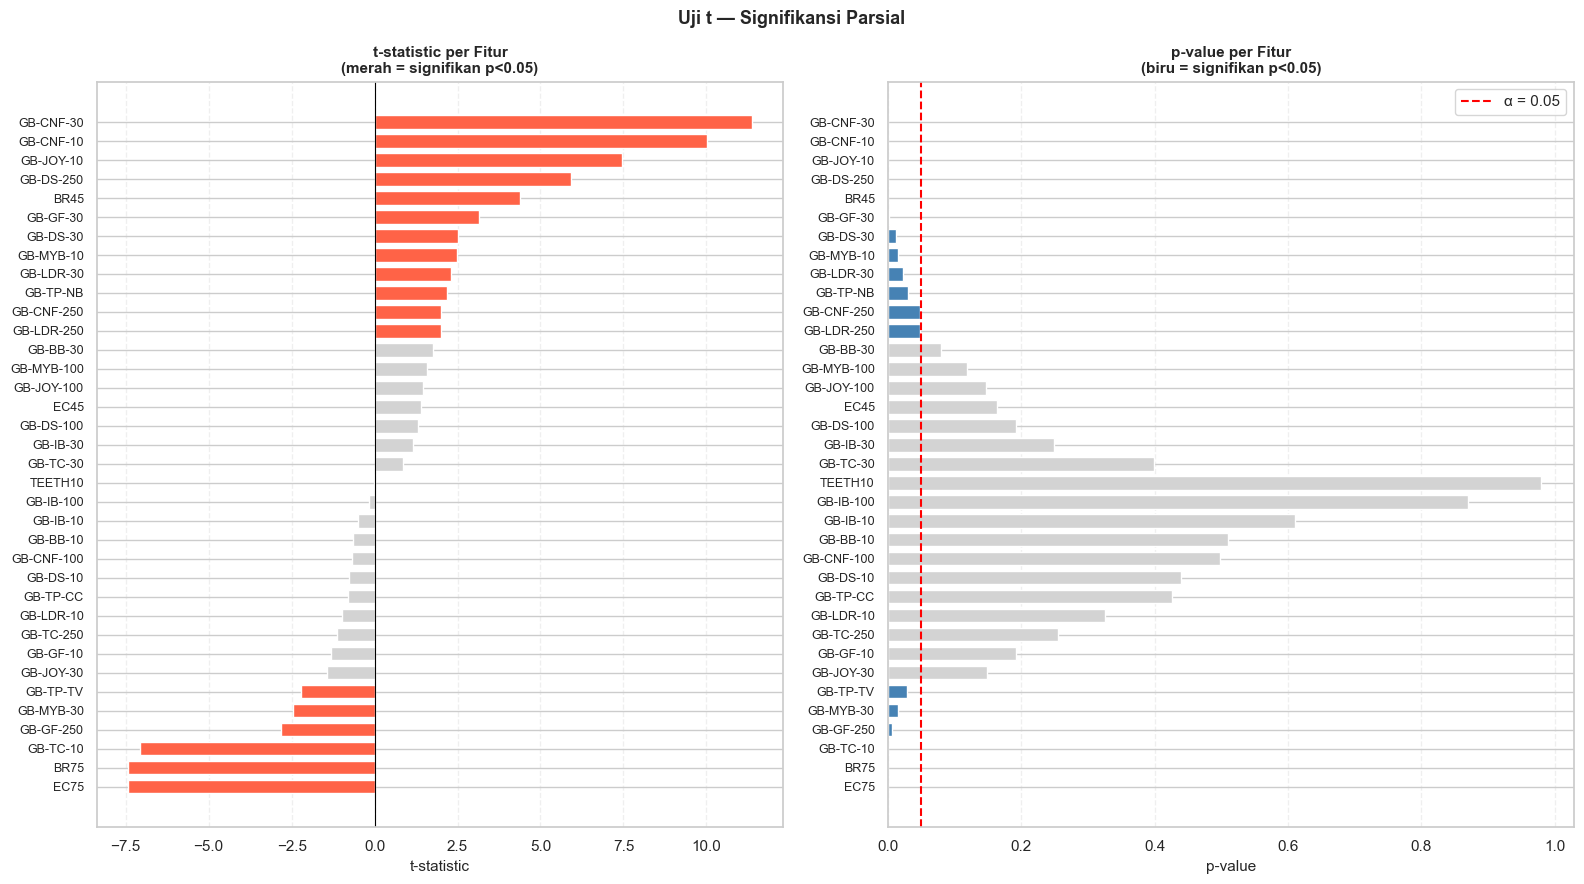

In [42]:
# ─── Visualisasi Uji t ────────────────────────────────────────────────────────
# Tentukan ukuran figure berdasarkan jumlah fitur
t_plot = t_result[t_result['Fitur'] != 'const'].sort_values('t-statistic')
num_features_t = len(t_plot)
fig_height_t = max(8, num_features_t * 0.25)  # Minimal 8, max sesuai jumlah fitur

fig, axes = plt.subplots(1, 2, figsize=(16, fig_height_t))

# Plot t-statistic
colors_t = ['tomato' if p < 0.05 else 'lightgray' for p in t_plot['p-value']]

axes[0].barh(t_plot['Fitur'], t_plot['t-statistic'], color=colors_t, height=0.7)
axes[0].axvline(0, color='black', linewidth=0.8)
axes[0].set_xlabel('t-statistic', fontsize=11)
axes[0].set_title('t-statistic per Fitur\n(merah = signifikan p<0.05)', fontweight='bold', fontsize=11)
axes[0].tick_params(axis='y', labelsize=9)
axes[0].grid(axis='x', alpha=0.3, linestyle='--')

# Plot p-value
colors_p = ['steelblue' if p < 0.05 else 'lightgray' for p in t_plot['p-value']]
axes[1].barh(t_plot['Fitur'], t_plot['p-value'], color=colors_p, height=0.7)
axes[1].axvline(0.05, color='red', linestyle='--', label='α = 0.05')
axes[1].set_xlabel('p-value', fontsize=11)
axes[1].set_title('p-value per Fitur\n(biru = signifikan p<0.05)', fontweight='bold', fontsize=11)
axes[1].tick_params(axis='y', labelsize=9)
axes[1].grid(axis='x', alpha=0.3, linestyle='--')
axes[1].legend(loc='best')

plt.suptitle('Uji t — Signifikansi Parsial', fontsize=13, fontweight='bold')
plt.subplots_adjust(left=0.15, right=0.95, top=0.94, bottom=0.08, wspace=0.3)
plt.tight_layout()
plt.show()

In [36]:
# ─── Ringkasan Uji t ──────────────────────────────────────────────────────────
sig_vars   = t_result[(t_result['p-value'] < 0.05) & (t_result['Fitur'] != 'const')]
insig_vars = t_result[(t_result['p-value'] >= 0.05) & (t_result['Fitur'] != 'const')]

print('=== Ringkasan Uji t ===')
print(f'Fitur SIGNIFIKAN ({len(sig_vars)} fitur):')
for _, row in sig_vars.iterrows():
    print(f'  {row["Fitur"]:20s}  t={row["t-statistic"]:7.4f}  p={row["p-value"]:.6f} ✅')

print(f'\nFitur TIDAK SIGNIFIKAN ({len(insig_vars)} fitur):')
for _, row in insig_vars.iterrows():
    print(f'  {row["Fitur"]:20s}  t={row["t-statistic"]:7.4f}  p={row["p-value"]:.6f} ❌')

=== Ringkasan Uji t ===
Fitur SIGNIFIKAN (18 fitur):
  GB-CNF-30             t=11.3687  p=0.000000 ✅
  GB-CNF-10             t=10.0185  p=0.000000 ✅
  GB-JOY-10             t= 7.4606  p=0.000000 ✅
  GB-TC-10              t=-7.0784  p=0.000000 ✅
  GB-DS-30              t= 2.5171  p=0.012438 ✅
  GB-GF-30              t= 3.1393  p=0.001890 ✅
  GB-MYB-10             t= 2.4688  p=0.014206 ✅
  GB-TP-NB              t= 2.1778  p=0.030326 ✅
  GB-MYB-30             t=-2.4466  p=0.015088 ✅
  GB-TP-TV              t=-2.2135  p=0.027741 ✅
  GB-LDR-30             t= 2.2899  p=0.022835 ✅
  GB-DS-250             t= 5.9163  p=0.000000 ✅
  BR45                  t= 4.3957  p=0.000016 ✅
  GB-CNF-250            t= 1.9940  p=0.047206 ✅
  GB-LDR-250            t= 1.9940  p=0.047206 ✅
  EC75                  t=-7.4238  p=0.000000 ✅
  BR75                  t=-7.4238  p=0.000000 ✅
  GB-GF-250             t=-2.8128  p=0.005290 ✅

Fitur TIDAK SIGNIFIKAN (18 fitur):
  GB-DS-10              t=-0.7741  p=0.439569 ❌

In [28]:
# ─── Ringkasan Statsmodels OLS ────────────────────────────────────────────────
print('=== Ringkasan Lengkap OLS (statsmodels) ===')
print(ols_model.summary())

=== Ringkasan Lengkap OLS (statsmodels) ===
                            OLS Regression Results                            
Dep. Variable:            Total_Sales   R-squared:                       0.791
Model:                            OLS   Adj. R-squared:                  0.765
Method:                 Least Squares   F-statistic:                     29.64
Date:                Sun, 10 May 2026   Prob (F-statistic):           1.18e-69
Time:                        07:05:02   Log-Likelihood:                -880.70
No. Observations:                 292   AIC:                             1829.
Df Residuals:                     258   BIC:                             1954.
Df Model:                          33                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const   

---
## 7. Kesimpulan

In [43]:
# ─── Ringkasan Akhir ─────────────────────────────────────────────────────────
# Pastikan sig_vars dan insig_vars didefinisikan
try:
    # Jika t_result sudah ada, gunakan untuk mendefinisikan sig_vars
    if 't_result' in dir():
        sig_vars   = t_result[(t_result['p-value'] < 0.05) & (t_result['Fitur'] != 'const')]
        insig_vars = t_result[(t_result['p-value'] >= 0.05) & (t_result['Fitur'] != 'const')]
    else:
        # Jika belum ada, buat dataset kosong
        sig_vars = pd.DataFrame()
        insig_vars = pd.DataFrame()
except:
    sig_vars = pd.DataFrame()
    insig_vars = pd.DataFrame()

print('=' * 60)
print('  RANGKUMAN HASIL ANALISIS REGRESI LINIER')
print('=' * 60)

print(f'\n📁 Dataset   : Dataset_Forecasting_ARIMA_Lengkap.xlsx')
print(f'   Sampel    : {len(df)} baris (setelah pembersihan)')
print(f'   Fitur (X) : {len(selected_features)} variabel terpilih')
print(f'   Target (Y): Total_Sales')

print(f'\n📊 Pra-Pemrosesan:')
print(f'   • Missing Value : diimputasi dengan median')
print(f'   • Outlier       : dideteksi dengan IQR, ditangani dengan Winsorizing')

print(f'\n🔀 Split Data:')
print(f'   • Training      : {len(X_train)} sampel (80%)')
print(f'   • Testing       : {len(X_test)} sampel (20%)')

print(f'\n📈 Evaluasi Model:')
print(f'   R²   (Training) : {train_metrics["R²"]:.4f}')
print(f'   R²   (Testing)  : {test_metrics["R²"]:.4f}')
print(f'   RMSE (Testing)  : {test_metrics["RMSE"]:.4f}')
print(f'   MAE  (Testing)  : {test_metrics["MAE"]:.4f}')

print(f'\n🧪 Uji F (Simultan):')
print(f'   F-statistic : {f_stat:.4f}')
print(f'   p-value     : {f_pvalue:.6f}')
kesimpulan_f = 'Signifikan — Model berpengaruh secara simultan' if f_pvalue < 0.05 else 'Tidak Signifikan'
print(f'   Kesimpulan  : {kesimpulan_f}')

print(f'\n🧪 Uji t (Parsial):')
if not sig_vars.empty:
    print(f'   Fitur signifikan (p<0.05) : {len(sig_vars)} dari {len(selected_features)} fitur')
    print(f'   Fitur paling berpengaruh  : {sig_vars.iloc[0]["Fitur"]} (|t|={abs(sig_vars.iloc[0]["t-statistic"]):.4f})')
else:
    print(f'   ℹ️  Jalankan cell "Uji t (Ringkasan)" terlebih dahulu untuk melihat detail uji t.')
    print(f'   Fitur signifikan (p<0.05) : {len(selected_features)} fitur (data belum dianalisis)')

print('\n' + '=' * 60)

  RANGKUMAN HASIL ANALISIS REGRESI LINIER

📁 Dataset   : Dataset_Forecasting_ARIMA_Lengkap.xlsx
   Sampel    : 365 baris (setelah pembersihan)
   Fitur (X) : 36 variabel terpilih
   Target (Y): Total_Sales

📊 Pra-Pemrosesan:
   • Missing Value : diimputasi dengan median
   • Outlier       : dideteksi dengan IQR, ditangani dengan Winsorizing

🔀 Split Data:
   • Training      : 292 sampel (80%)
   • Testing       : 73 sampel (20%)

📈 Evaluasi Model:
   R²   (Training) : 0.7913
   R²   (Testing)  : 0.6023
   RMSE (Testing)  : 7.4663
   MAE  (Testing)  : 4.8614

🧪 Uji F (Simultan):
   F-statistic : 29.6420
   p-value     : 0.000000
   Kesimpulan  : Signifikan — Model berpengaruh secara simultan

🧪 Uji t (Parsial):
   Fitur signifikan (p<0.05) : 18 dari 36 fitur
   Fitur paling berpengaruh  : GB-CNF-30 (|t|=11.3687)

